In [1]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Country-data.csv"

# Load the latest version
country_data = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "rohan0301/unsupervised-learning-on-country-data",
    file_path
)

c:\Users\avanindra Bose\ML Tips\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 9.01k/9.01k [00:00<00:00, 856kB/s]


In [3]:
country_data

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [4]:
country_data.shape

(167, 10)

In [6]:
country_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [7]:
# drop the country column for clustering

data_for_clustering = country_data.drop(columns=["country"])

# scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_clustering)

# apply agglomerative clustering
linkage_matrix = linkage(scaled_data, method="ward")

In [14]:
linkage_matrix

array([[4.10000000e+01, 1.21000000e+02, 2.70510920e-01, 2.00000000e+00],
       [7.50000000e+01, 1.39000000e+02, 3.45939626e-01, 2.00000000e+00],
       [2.40000000e+01, 8.50000000e+01, 4.23131474e-01, 2.00000000e+00],
       [1.11000000e+02, 1.58000000e+02, 4.94330379e-01, 2.00000000e+00],
       [6.00000000e+01, 1.22000000e+02, 5.44105161e-01, 2.00000000e+00],
       [1.00000000e+02, 1.69000000e+02, 5.58805736e-01, 3.00000000e+00],
       [1.00000000e+00, 4.80000000e+01, 5.59540632e-01, 2.00000000e+00],
       [5.30000000e+01, 1.44000000e+02, 5.68799380e-01, 2.00000000e+00],
       [2.90000000e+01, 5.40000000e+01, 5.90319960e-01, 2.00000000e+00],
       [2.00000000e+01, 1.30000000e+02, 6.04562360e-01, 2.00000000e+00],
       [6.00000000e+00, 7.60000000e+01, 6.13397046e-01, 2.00000000e+00],
       [5.60000000e+01, 1.29000000e+02, 6.27531275e-01, 2.00000000e+00],
       [4.30000000e+01, 1.35000000e+02, 6.39912838e-01, 2.00000000e+00],
       [5.10000000e+01, 9.00000000e+01, 6.49519933e

In [29]:
linkage_matrix[:,3]

array([  2.,   2.,   2.,   2.,   2.,   3.,   2.,   2.,   2.,   2.,   2.,
         2.,   2.,   2.,   2.,   2.,   2.,   2.,   3.,   2.,   2.,   2.,
         2.,   2.,   2.,   2.,   2.,   2.,   4.,   3.,   2.,   2.,   2.,
         4.,   2.,   2.,   2.,   2.,   3.,   2.,   3.,   2.,   2.,   3.,
         3.,   2.,   3.,   3.,   2.,   2.,   2.,   4.,   3.,   2.,   3.,
         3.,   3.,   2.,   3.,   2.,   2.,   4.,   4.,   4.,   2.,   4.,
         2.,   2.,   6.,   3.,   2.,   2.,   3.,   2.,   2.,   3.,   2.,
         5.,   5.,   6.,   5.,   5.,   4.,   6.,   5.,   3.,   4.,   4.,
         3.,   3.,   9.,   4.,   6.,   5.,   4.,   7.,   2.,   7.,   6.,
         6.,   3.,   3.,   3.,   2.,   3.,   5.,   3.,   5.,   3.,   3.,
         6.,   8.,   4.,   3.,   2.,   6.,   7.,  10.,   7.,  11.,   6.,
         2.,   4.,  10.,   4.,   7.,   4.,  11.,  10.,   6.,   4.,  14.,
         7.,  12.,  12.,  17.,  11.,  25.,  15.,  10.,   7.,   2.,  19.,
        17.,   5.,  12.,  18.,   6.,  26.,   3.,  3

### `linkage_matrix` structure

| Column | Name              | Meaning                                                        |
|:------:|-------------------|-----------------------------------------------------------------|
| 0      | `cluster_1`       | ID of the first cluster being merged                            |
| 1      | `cluster_2`       | ID of the second cluster being merged                           |
| 2      | `distance`        | Linkage distance at which these two clusters were merged        |
| 3      | `number_of_points`| Total number of original points contained in the new merged cluster |

**Row format:**
- Each row = one merge step in the hierarchical clustering process.
- Cluster IDs `0` to `n-1` refer to the original data points.
- Cluster IDs `n` and above refer to *newly formed clusters* from earlier merge steps (row index `n` in the matrix = cluster ID `n + i`, where `i` is the original number of points).
- The matrix has `n - 1` rows total, since it takes exactly `n - 1` merges to combine `n` points into a single cluster.

linkage(scaled_data, method="ward") performs agglomerative hierarchical clustering using Ward's minimum-variance criterion and returns a linkage matrix containing the complete sequence of \(n-1\) cluster merges.

In [12]:
linkage_matrix.shape

(166, 4)

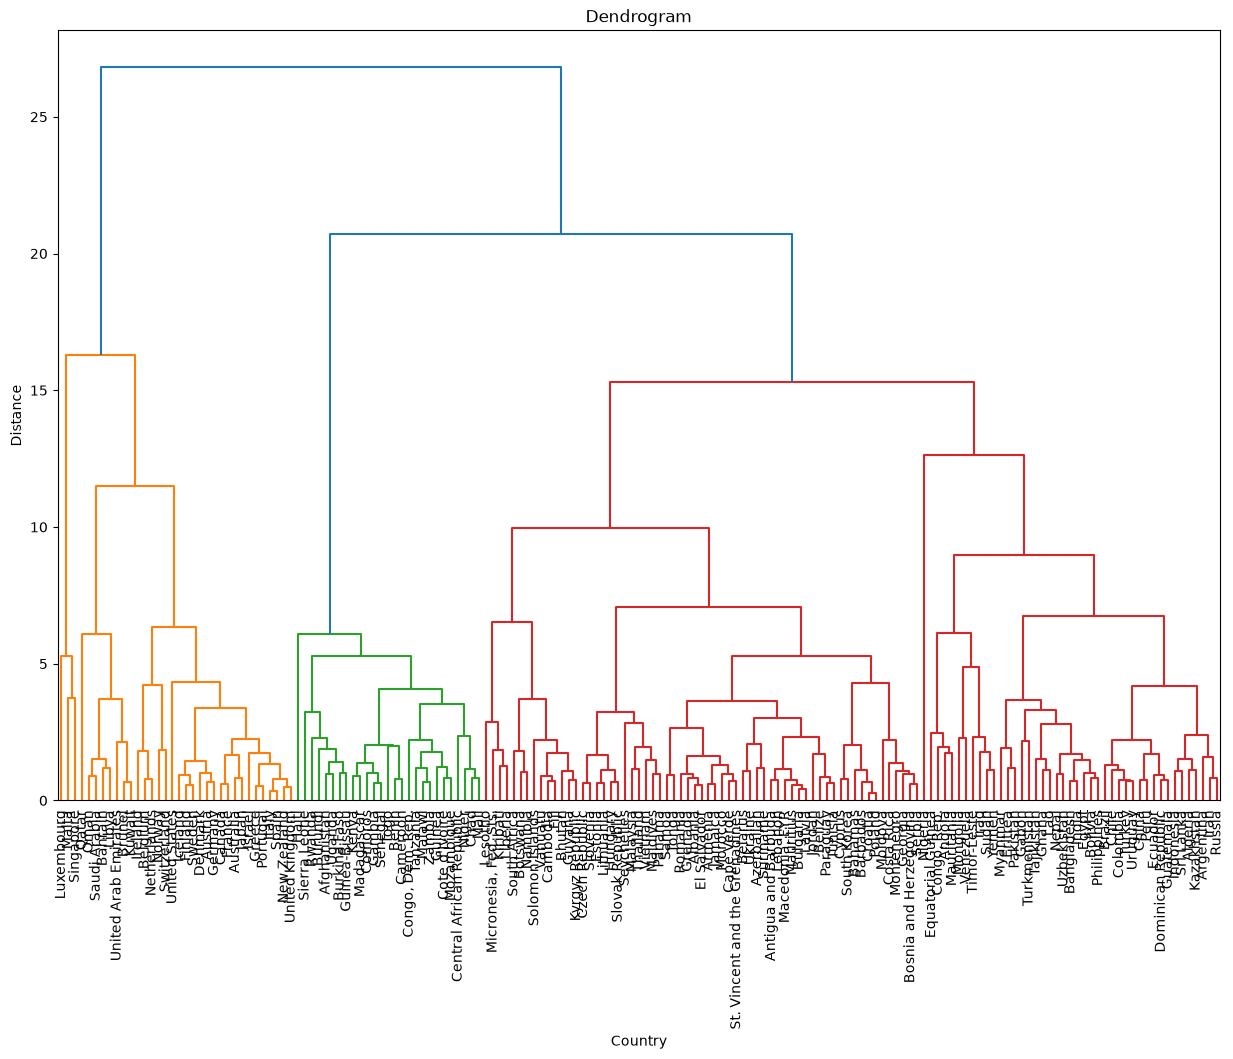

In [17]:
plt.figure(figsize=(15, 10))
dendrogram(linkage_matrix,
           labels=country_data["country"].values,
           leaf_font_size=10, leaf_rotation=90)
plt.xlabel("Country")
plt.ylabel("Distance")
plt.title("Dendrogram")
plt.show()

# Understanding Fcluster

## `fcluster()`

`fcluster()` converts the hierarchical clustering represented by the linkage matrix into **flat cluster labels**.

> **Mental model:** `fcluster = cut hierarchy + assign labels`

### Syntax

```python
labels = fcluster(Z, t, criterion="maxclust")

1. maxclust
labels = fcluster(linkage_matrix, 3, criterion="maxclust")

Means:

"Cut the hierarchy to obtain at most 3 clusters."

Here:

3 → number of clusters
2. distance
labels = fcluster(linkage_matrix, 5, criterion="distance")

Means:

"Cut the dendrogram at linkage distance = 5."

Here:

5 → distance threshold

The resulting number of clusters is determined by the cut.

Output

fcluster() returns an array containing the cluster label for every observation.

Example:

[1, 1, 2, 2, 1, 3, 3]

This means:

Point 1 → Cluster 1
Point 2 → Cluster 1
Point 3 → Cluster 2
Point 4 → Cluster 2
...

The numbers 1, 2, 3 are just cluster identifiers; they have no inherent meaning.

In [31]:
labels = fcluster(
    linkage_matrix,
    3,
    criterion="maxclust"
)

print(labels)

[2 3 3 3 3 3 3 1 1 3 3 1 3 3 3 1 3 2 3 3 3 3 3 1 3 2 2 3 2 1 3 2 2 3 3 3 2
 2 3 3 2 3 3 3 1 3 3 3 3 3 3 3 3 1 1 3 2 3 1 3 1 3 3 2 2 3 2 3 1 3 3 3 3 1
 1 1 3 1 3 3 2 3 1 3 3 3 3 3 3 1 3 1 3 2 2 3 3 2 1 3 3 3 3 3 3 3 2 3 3 3 1
 1 2 3 1 1 3 3 3 3 3 3 1 1 3 3 2 3 1 2 3 3 2 1 3 3 3 3 3 1 3 3 3 3 1 1 3 2
 3 3 2 3 3 3 3 2 3 1 1 1 3 3 3 3 3 3 2]


In [18]:
country_data = country_data.drop(columns=["country"])

In [33]:
from scipy.cluster.hierarchy import fcluster

# assigning countries to cluster for each level 2
cluster_1 = fcluster(linkage_matrix, 3, criterion="maxclust")

# adding these cluster assignments to data
country_data["cluster_1"] = cluster_1

mean_features_2 = country_data.groupby("cluster_1").mean()

mean_features_2

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_2
cluster_1,,,,,,,,,,
1,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235,1.0
2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889,2.0
3,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925,2.0


In [34]:
# assigning countries to cluster for each level 2
cluster_1 = fcluster(linkage_matrix, 2, criterion="maxclust")

# adding these cluster assignments to data
country_data["cluster_2"] = cluster_2

mean_features_2 = country_data.groupby("cluster_2").mean()

mean_features_2

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_1
cluster_2,,,,,,,,,,
1,5.961765,58.508824,8.501176,48.902941,47588.235294,4.11550,79.982353,1.888529,43170.588235,1.000000
2,46.529323,36.660895,6.384812,46.375683,9362.127820,8.71909,68.145865,3.218797,5242.210526,2.796992
